# ✈️ Aviation Operational Performance Analysis — January 2025  PART - 2

## 📌 Project Objective

This project analyzes U.S. aviation flight operations for January 2025 to identify:

- Flight volume and operational scale
- Delay and cancellation performance
- Airline reliability
- Airport and route performance
- Major causes of flight delays
- Operational efficiency opportunities

## 🛠 Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## 📊 Analysis Workflow

1. Import libraries
2. Load dataset
3. Inspect dataset
4. Check data quality
5. Prepare data
6. Exploratory data analysis
7. Business insights
8. Recommendations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display


In [2]:
# LOADING DATA
df=pd.read_csv('aviation_cleaned_JAN2025.csv',low_memory=False)
df.head(1)

,Year,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,...,DivActualElapsedTime,DivArrDelay,DivDistance,Div1Airport,Div1TailNum,IsDelayed,IsDelayed15,IsCancelled,IsDiverted,IsSeverelyDelayed
0,2025,1,3,01-01-2025,AA,19805,AA,N104NN,1,12478,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0


# INSIGHT 11 — Route Delay Performance
-  Are delays concentrated around specific airport-to-airport connections

In [3]:
# PREVIOUS FILE IMPORTANT FACTORS
df["FlightDate"] = pd.to_datetime(
    df["FlightDate"],
    format="%d-%m-%Y"
)

df["Route"] = df["Origin"] + " → " + df["Dest"]

route_flights = (
    df.groupby("Route")
      .size()
      .reset_index(name="Total_Flights")
)

route_delays = (
    df.groupby("Route")["IsDelayed15"]
      .sum()
      .reset_index(name="Delayed_15_Flights")
)

route_delay_analysis = route_flights.merge(
    route_delays,
    on="Route"
)

route_delay_analysis["Delay_Rate"] = (
    route_delay_analysis["Delayed_15_Flights"]
    / route_delay_analysis["Total_Flights"]
    * 100
).round(2)

In [4]:
minimum_flights = 100

route_reliable_sample = (
    route_delay_analysis[
        route_delay_analysis["Total_Flights"] >= minimum_flights
    ]
    .copy()
)

In [5]:
route_reliability = (
    route_reliable_sample[
        [
            "Route",
            "Total_Flights",
            "Delayed_15_Flights",
            "Delay_Rate"
        ]
    ]
    .sort_values("Delay_Rate", ascending=False)
)

route_reliability.head(15)

,Route,Total_Flights,Delayed_15_Flights,Delay_Rate
2217,HSV → DCA,101,45,44.55
3636,ORD → ASE,143,63,44.06
1348,DEN → MAF,119,50,42.02
582,BOS → PBI,238,99,41.60
590,BOS → RSW,204,83,40.69
1198,DCA → HSV,100,40,40.00
603,BOS → TPA,212,83,39.15
1270,DEN → BIS,124,48,38.71
636,BUF → DCA,114,44,38.60
428,BIS → DEN,124,47,37.90


In [6]:
route_reliability["Reliability_Level"] = pd.cut(
    route_reliability["Delay_Rate"],
    bins=[-np.inf, 20, 30, 40, np.inf],
    labels=[
        "Good",
        "Moderate",
        "Poor",
        "Critical"
    ]
)

In [7]:
route_reliability["Reliability_Level"].value_counts()

Reliability_Level
Good        1077
Moderate     457
Poor          69
Critical       5
Name: count, dtype: int64

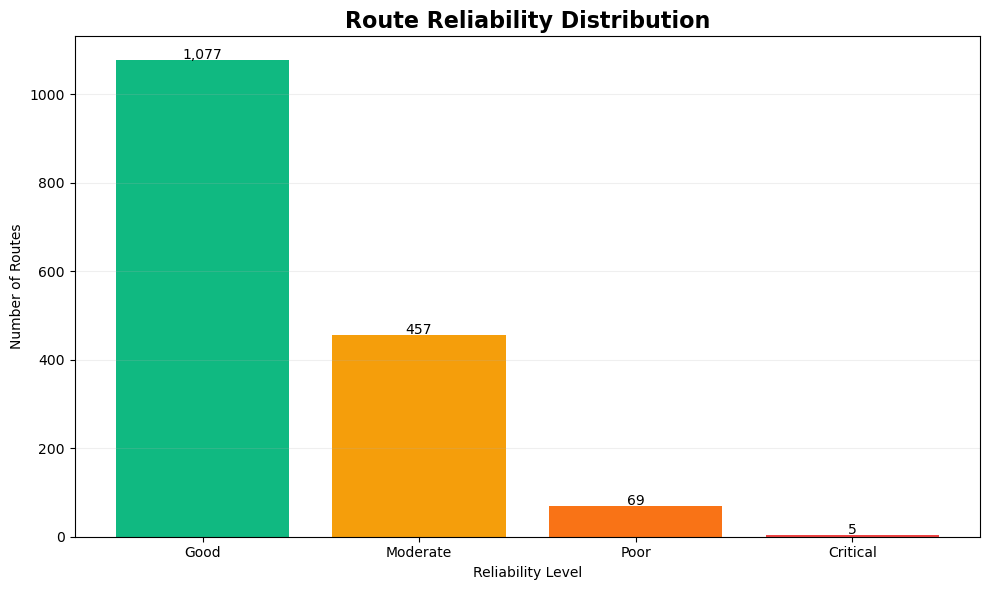

In [8]:
# VISUALISATION
reliability_counts = (
    route_reliability["Reliability_Level"]
    .value_counts()
    .reindex(
        ["Good", "Moderate", "Poor", "Critical"]
    )
    .fillna(0)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    reliability_counts.index,
    reliability_counts.values,
    color=["#10B981", "#F59E0B", "#F97316", "#EF4444"]
)

plt.xlabel("Reliability Level")
plt.ylabel("Number of Routes")

plt.title(
    "Route Reliability Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.grid(axis="y", alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{int(height):,}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [9]:
# CRITICAL ROUTES
critical_routes = (
    route_reliability[
        route_reliability["Reliability_Level"] == "Critical"
    ]
    .sort_values(
        ["Delay_Rate", "Total_Flights"],
        ascending=[False, False]
    )
)

critical_routes.head(15)

,Route,Total_Flights,Delayed_15_Flights,Delay_Rate,Reliability_Level
2217,HSV → DCA,101,45,44.55,Critical
3636,ORD → ASE,143,63,44.06,Critical
1348,DEN → MAF,119,50,42.02,Critical
582,BOS → PBI,238,99,41.60,Critical
590,BOS → RSW,204,83,40.69,Critical


In [11]:
# HIGH VOLUME
traffic_threshold = route_reliable_sample["Total_Flights"].median()

print(f"Traffic Threshold: {traffic_threshold:,.0f} flights")
delay_threshold = route_reliable_sample["Delay_Rate"].median()

print(f"Traffic Threshold: {traffic_threshold:,.0f} flights")
print(f"Delay Threshold: {delay_threshold:.2f}%")
critical_high_volume = (
    critical_routes[
        critical_routes["Total_Flights"] >= traffic_threshold
    ]
    .sort_values(
        ["Delay_Rate", "Total_Flights"],
        ascending=[False, False]
    )
)

critical_high_volume.head(15)

Traffic Threshold: 176 flights
Traffic Threshold: 176 flights
Delay Threshold: 17.31%


,Route,Total_Flights,Delayed_15_Flights,Delay_Rate,Reliability_Level
582,BOS → PBI,238,99,41.60,Critical
590,BOS → RSW,204,83,40.69,Critical


###  Business Interpretation
THIS INTERPRETS THAT ROUTE HSV -> DCA ROUTE IS MOST CRITICAL WITH 44.55% DELAY RATE

# INSIGHT 12 — Day-of-Week Flight Volume
-  Which days of the week have the highest flight volume

In [22]:
day_volume=df.groupby('DayOfWeek').size().reset_index(name='Total_Flights')
day_volume

,DayOfWeek,Total_Flights
0,1,65740
1,2,58318
2,3,74450
3,4,83082
4,5,82585
5,6,57139
6,7,66032


In [25]:
# MAPPING ACCORDING TO CATEGORICAL NAME
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
day_volume["Day_Name"] = day_volume["DayOfWeek"].map(day_names)
day_volume["Day_Name"] = pd.Categorical(
    day_volume["Day_Name"],
    categories=day_order,
    ordered=True
)

day_volume = day_volume.sort_values("Day_Name")
day_volume

,DayOfWeek,Total_Flights,Traffic_Share,Day_Name
0,1,65740,13.49,Monday
1,2,58318,11.97,Tuesday
2,3,74450,15.28,Wednesday
3,4,83082,17.05,Thursday
4,5,82585,16.95,Friday
5,6,57139,11.72,Saturday
6,7,66032,13.55,Sunday


In [23]:
# TRAFFIC SHARE ACCORDING TO DAY
total_flights = len(df)

day_volume["Traffic_Share"] = (
    day_volume["Total_Flights"]
    / total_flights
    * 100
).round(2)

day_volume

,DayOfWeek,Total_Flights,Traffic_Share
0,1,65740,13.49
1,2,58318,11.97
2,3,74450,15.28
3,4,83082,17.05
4,5,82585,16.95
5,6,57139,11.72
6,7,66032,13.55


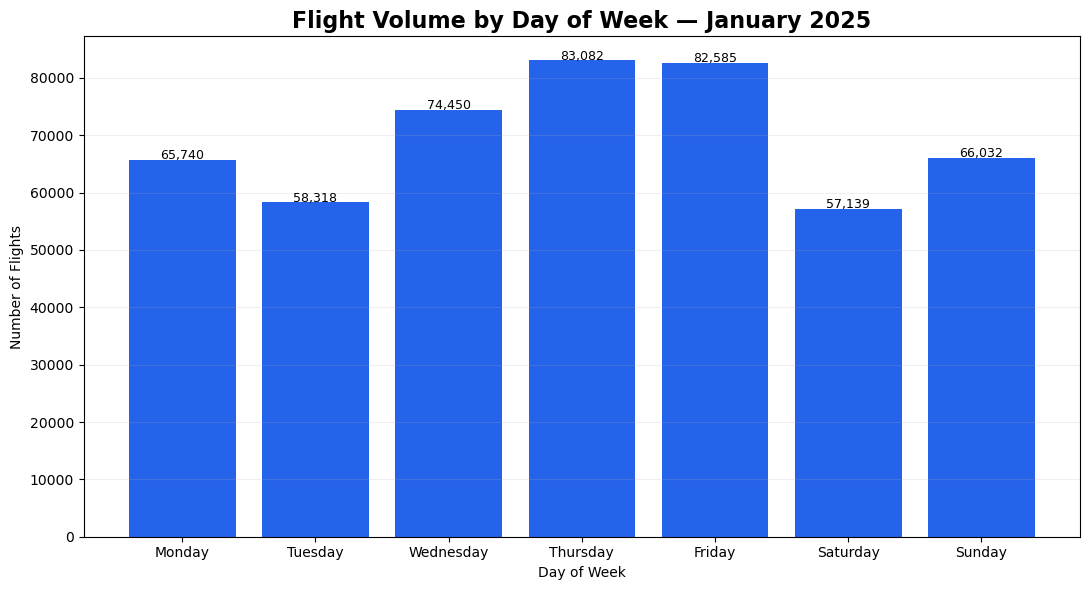

In [26]:
plt.figure(figsize=(11, 6))

bars = plt.bar(
    day_volume["Day_Name"],
    day_volume["Total_Flights"],
    color="#2563EB"
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Flights")

plt.title(
    "Flight Volume by Day of Week — January 2025",
    fontsize=16,
    fontweight="bold"
)

plt.grid(axis="y", alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 100,
        f"{int(height):,}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [31]:
# busiest and quietest days
busiest_day=day_volume.loc[day_volume['Total_Flights'].idxmax()]
print(
    f"Busiest day: {busiest_day['Day_Name']} "
    f"({busiest_day['Total_Flights']:,} flights)"
)

quietest_day = day_volume.loc[
    day_volume["Total_Flights"].idxmin()
]
print(
    f"Quietest day: {quietest_day['Day_Name']} "
    f"({quietest_day['Total_Flights']:,} flights)"
)


Busiest day: Thursday (83,082 flights)
Quietest day: Saturday (57,139 flights)


###  Business Interpretation
[Busiest day] has the highest flight volume with [83082] flights, while [quietest day] has the lowest with [57139] flights. This indicates that flight activity is not evenly distributed throughout the week. Higher-volume days may require greater staffing, airport capacity, gate availability, and operational planning.

# INSIGHT 13 — Day-of-Week Delay Rate
-  Are some days of the week more delay-prone than others

In [32]:
day_flights=df.groupby('DayOfWeek').size().reset_index(name='Total_Flights')
day_flights

,DayOfWeek,Total_Flights
0,1,65740
1,2,58318
2,3,74450
3,4,83082
4,5,82585
5,6,57139
6,7,66032


In [34]:
# 15 minute + delay rate
day_delays=df.groupby('DayOfWeek')['IsDelayed15'].sum().reset_index(name='Delayed_15_Flights')
day_delays

,DayOfWeek,Delayed_15_Flights
0,1,14672
1,2,8771
2,3,9626
3,4,13606
4,5,15302
5,6,12384
6,7,14469


In [35]:
# Merge Both
day_delay_analysis = day_flights.merge(
    day_delays,
    on="DayOfWeek"
)
# Delay Rate
day_delay_analysis["Delay_Rate"] = (
    day_delay_analysis["Delayed_15_Flights"]
    / day_delay_analysis["Total_Flights"]
    * 100
).round(2)


In [36]:
day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

day_delay_analysis["Day_Name"] = (
    day_delay_analysis["DayOfWeek"]
    .map(day_names)
)
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_delay_analysis["Day_Name"] = pd.Categorical(
    day_delay_analysis["Day_Name"],
    categories=day_order,
    ordered=True
)

day_delay_analysis = (
    day_delay_analysis
    .sort_values("Day_Name")
)

day_delay_analysis

,DayOfWeek,Total_Flights,Delayed_15_Flights,Delay_Rate,Day_Name
0,1,65740,14672,22.32,Monday
1,2,58318,8771,15.04,Tuesday
2,3,74450,9626,12.93,Wednesday
3,4,83082,13606,16.38,Thursday
4,5,82585,15302,18.53,Friday
5,6,57139,12384,21.67,Saturday
6,7,66032,14469,21.91,Sunday


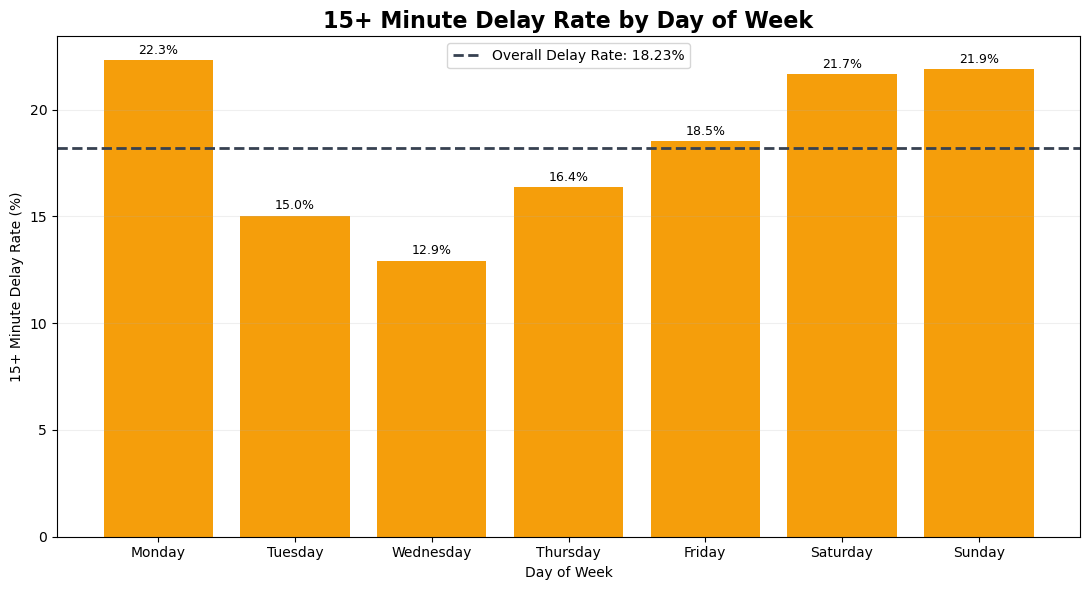

In [38]:
overall_delay_rate = df["IsDelayed15"].mean() * 100

plt.figure(figsize=(11, 6))

bars = plt.bar(
    day_delay_analysis["Day_Name"],
    day_delay_analysis["Delay_Rate"],
    color="#F59E0B"
)

plt.axhline(
    overall_delay_rate,
    color="#374151",
    linestyle="--",
    linewidth=2,
    label=f"Overall Delay Rate: {overall_delay_rate:.2f}%"
)

plt.xlabel("Day of Week")
plt.ylabel("15+ Minute Delay Rate (%)")

plt.title(
    "15+ Minute Delay Rate by Day of Week",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{height:.1f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [39]:
# HIGHEST AND LOWEST DAY
highest_delay_day = day_delay_analysis.loc[
    day_delay_analysis["Delay_Rate"].idxmax()
]

lowest_delay_day = day_delay_analysis.loc[
    day_delay_analysis["Delay_Rate"].idxmin()
]

print(
    f"Highest delay day: "
    f"{highest_delay_day['Day_Name']} "
    f"({highest_delay_day['Delay_Rate']:.2f}%)"
)

print(
    f"Lowest delay day: "
    f"{lowest_delay_day['Day_Name']} "
    f"({lowest_delay_day['Delay_Rate']:.2f}%)"
)


Highest delay day: Monday (22.32%)
Lowest delay day: Wednesday (12.93%)


###  Business Interpretation
[Highest-delay day] recorded the highest 15+ minute delay rate at [22.3]%, compared with the overall network rate of [18.23]%. In contrast, [lowest-delay day] had the lowest delay rate at [12.9]%. This suggests that operational reliability varies across the week, and higher-delay days may require closer monitoring of staffing, airport capacity, and operational scheduling.

# INSIGHT 14 — Departure Time-Block Performance
-  Which scheduled departure time blocks have the highest delay rates

In [40]:
# FLIGHTS ACCORDING TO DEPARTURE TIME
timeblock_flights = (
    df.groupby("DepTimeBlk")
      .size()
      .reset_index(name="Total_Flights")
)
timeblock_delays = (
    df.groupby("DepTimeBlk")["IsDelayed15"]
      .sum()
      .reset_index(name="Delayed_15_Flights")
)

In [42]:
timeblock_analysis = timeblock_flights.merge(
    timeblock_delays,
    on="DepTimeBlk"
)
timeblock_analysis

,DepTimeBlk,Total_Flights,Delayed_15_Flights
0,0001-0559,12958,1556
1,0600-0659,33003,3983
2,0700-0759,34739,4900
3,0800-0859,35181,5385
4,0900-0959,29244,4499
5,1000-1059,29802,5022
6,1100-1159,33011,5664
7,1200-1259,29195,5382
8,1300-1359,29839,5554
9,1400-1459,29308,5891


In [43]:
timeblock_analysis["Delay_Rate"] = (
    timeblock_analysis["Delayed_15_Flights"]
    / timeblock_analysis["Total_Flights"]
    * 100
).round(2)

In [44]:
# SORT ACCORDING TO TIME
df["DepTimeBlk"].unique()

array(['0600-0659', '0700-0759', '0800-0859', '0900-0959', '1100-1159',
       '1000-1059', '1500-1559', '1400-1459', '1300-1359', '1700-1759',
       '1600-1659', '2200-2259', '2300-2359', '1800-1859', '2100-2159',
       '1900-1959', '2000-2059', '1200-1259', '0001-0559'], dtype=object)

In [45]:
timeblock_analysis = (
    timeblock_analysis
    .sort_values("DepTimeBlk")
)

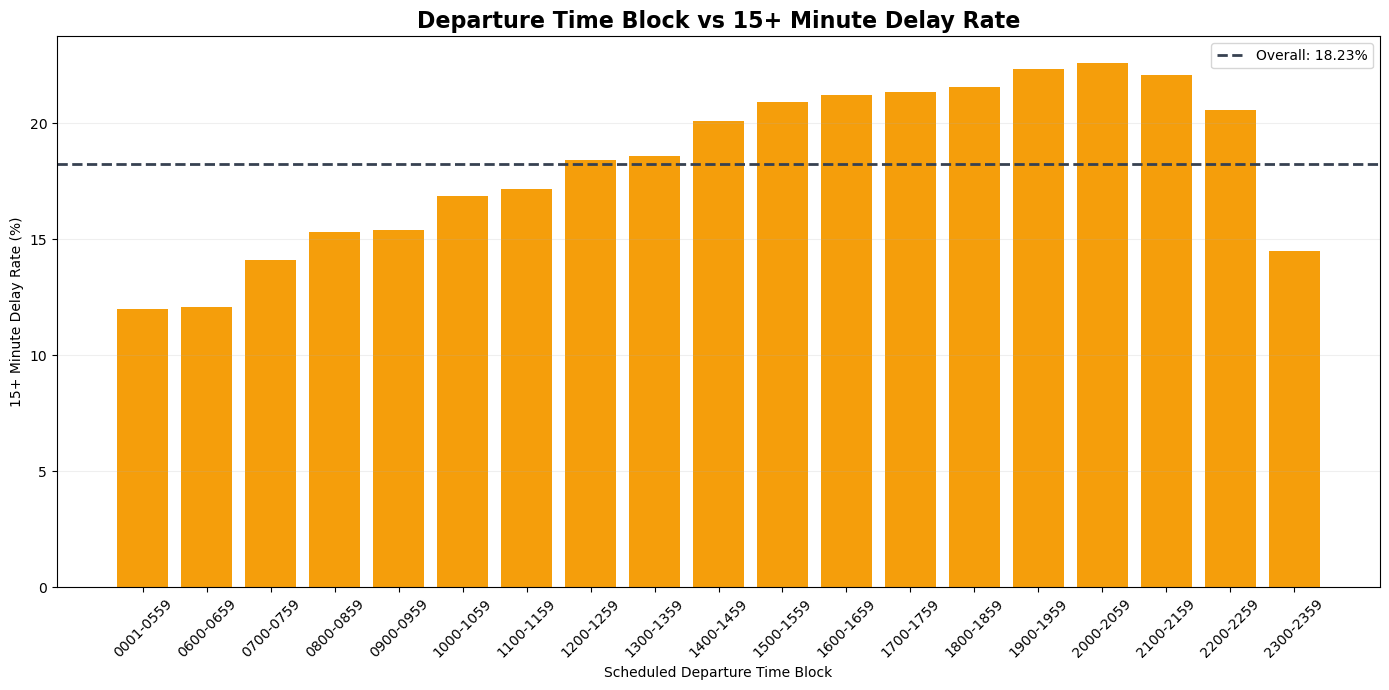

In [47]:
# VISUALISATION WITH THRESHOLD
overall_delay_rate = df["IsDelayed15"].mean() * 100

plt.figure(figsize=(14, 7))

bars = plt.bar(
    timeblock_analysis["DepTimeBlk"],
    timeblock_analysis["Delay_Rate"],
    color="#F59E0B"
)

plt.axhline(
    overall_delay_rate,
    color="#374151",
    linestyle="--",
    linewidth=2,
    label=f"Overall: {overall_delay_rate:.2f}%"
)

plt.xlabel("Scheduled Departure Time Block")
plt.ylabel("15+ Minute Delay Rate (%)")

plt.title(
    "Departure Time Block vs 15+ Minute Delay Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


In [48]:
worst_timeblocks = (
    timeblock_analysis
    .sort_values("Delay_Rate", ascending=False)
)

worst_timeblocks.head(10)

,DepTimeBlk,Total_Flights,Delayed_15_Flights,Delay_Rate
15,2000-2059,20829,4712,22.62
14,1900-1959,24604,5502,22.36
16,2100-2159,13152,2903,22.07
13,1800-1859,30432,6566,21.58
12,1700-1759,32134,6856,21.34
11,1600-1659,28518,6054,21.23
10,1500-1559,28535,5964,20.90
17,2200-2259,9415,1938,20.58
9,1400-1459,29308,5891,20.10
8,1300-1359,29839,5554,18.61


###  Business Interpretation
The [time block] departure period recorded the highest 15+ minute delay rate at [22.62]%, compared with the overall network rate of [18.23]%. This indicates that operational reliability varies across departure periods. Time blocks with consistently higher delay rates may require closer monitoring of aircraft turnaround, airport congestion, staffing, and scheduling capacity.

# INSIGHT 15 — Arrival Time-Block Performance
-  Which scheduled arrival time blocks have the highest 15+ minute delay rates

In [49]:
# CHECK UNIQUE ARRIVAL TIME
df["ArrTimeBlk"].unique()

array(['1000-1059', '1600-1659', '1500-1559', '1200-1259', '1100-1159',
       '1400-1459', '2000-2059', '2300-2359', '2200-2259', '1900-1959',
       '0600-0659', '2100-2159', '0700-0759', '1300-1359', '0900-0959',
       '0001-0559', '1800-1859', '1700-1759', '0800-0859'], dtype=object)

In [50]:
arrival_timeblock_flights = (
    df.groupby("ArrTimeBlk")
      .size()
      .reset_index(name="Total_Flights")
)

arrival_timeblock_flights

,ArrTimeBlk,Total_Flights
0,0001-0559,9486
1,0600-0659,5337
2,0700-0759,16587
3,0800-0859,23267
4,0900-0959,27885
5,1000-1059,30925
6,1100-1159,28750
7,1200-1259,30558
8,1300-1359,29345
9,1400-1459,29380


In [51]:
# ARRIVAL DELAY
arrival_timeblock_delays = (
    df.groupby("ArrTimeBlk")["IsDelayed15"]
      .sum()
      .reset_index(name="Delayed_15_Flights")
)

arrival_timeblock_delays

,ArrTimeBlk,Delayed_15_Flights
0,0001-0559,2058
1,0600-0659,668
2,0700-0759,2070
3,0800-0859,3063
4,0900-0959,3871
5,1000-1059,4648
6,1100-1159,4434
7,1200-1259,4879
8,1300-1359,4982
9,1400-1459,5223


In [52]:
# MERGE TABLE
arrival_timeblock_analysis = arrival_timeblock_flights.merge(
    arrival_timeblock_delays,
    on="ArrTimeBlk"
)

arrival_timeblock_analysis

,ArrTimeBlk,Total_Flights,Delayed_15_Flights
0,0001-0559,9486,2058
1,0600-0659,5337,668
2,0700-0759,16587,2070
3,0800-0859,23267,3063
4,0900-0959,27885,3871
5,1000-1059,30925,4648
6,1100-1159,28750,4434
7,1200-1259,30558,4879
8,1300-1359,29345,4982
9,1400-1459,29380,5223


In [53]:
arrival_timeblock_analysis["Delay_Rate"] = (
    arrival_timeblock_analysis["Delayed_15_Flights"]
    / arrival_timeblock_analysis["Total_Flights"]
    * 100
).round(2)

In [54]:
arrival_timeblock_analysis = (
    arrival_timeblock_analysis
    .sort_values("ArrTimeBlk")
)

In [55]:
# BENCHMARK
overall_delay_rate = (
    df["IsDelayed15"].mean() * 100
)

print(
    f"Overall 15+ minute delay rate: "
    f"{overall_delay_rate:.2f}%"
)

Overall 15+ minute delay rate: 18.23%


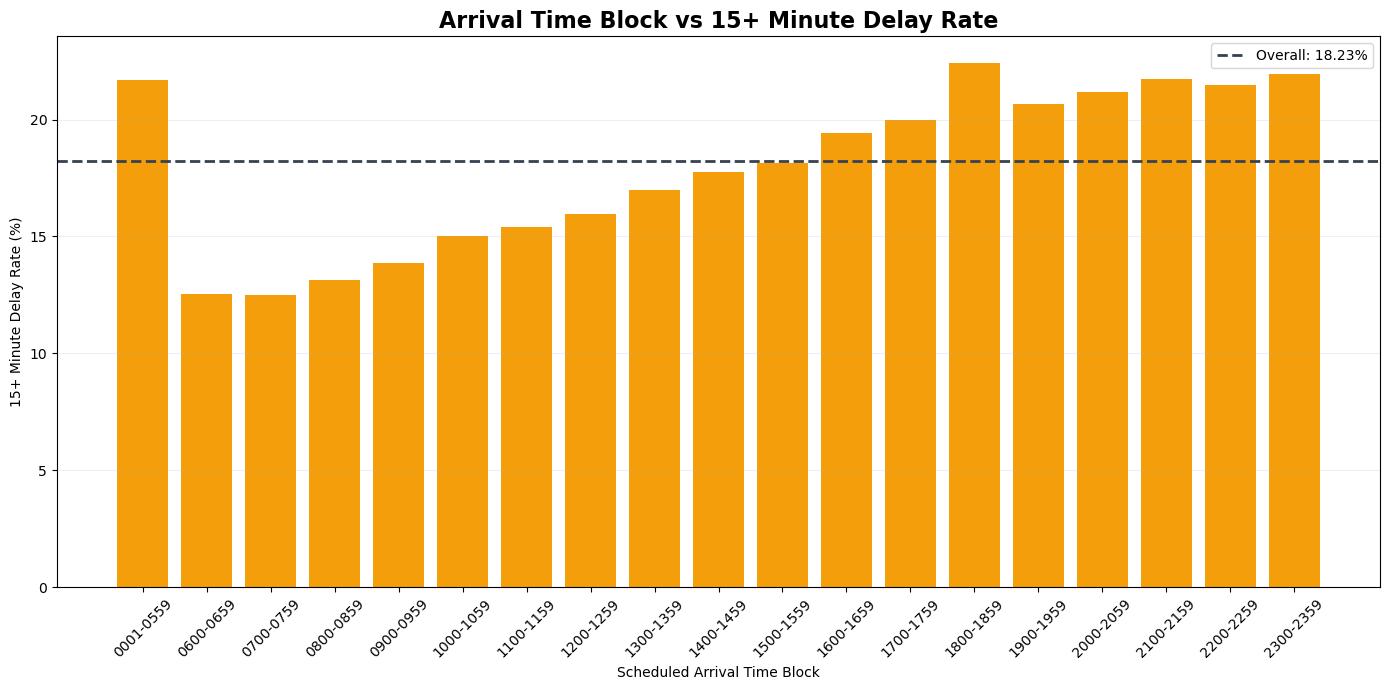

In [56]:
plt.figure(figsize=(14, 7))

bars = plt.bar(
    arrival_timeblock_analysis["ArrTimeBlk"],
    arrival_timeblock_analysis["Delay_Rate"],
    color="#F59E0B"
)

plt.axhline(
    overall_delay_rate,
    color="#374151",
    linestyle="--",
    linewidth=2,
    label=f"Overall: {overall_delay_rate:.2f}%"
)

plt.xlabel("Scheduled Arrival Time Block")
plt.ylabel("15+ Minute Delay Rate (%)")

plt.title(
    "Arrival Time Block vs 15+ Minute Delay Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [57]:
arrival_timeblock_analysis["vs_Overall"] = (
    arrival_timeblock_analysis["Delay_Rate"]
    - overall_delay_rate
).round(2)

In [58]:
# WORST ARRIVAL FLIGHT
worst_arrival_timeblocks = (
    arrival_timeblock_analysis
    .sort_values(
        "Delay_Rate",
        ascending=False
    )
)

worst_arrival_timeblocks.head(10)

,ArrTimeBlk,Total_Flights,Delayed_15_Flights,Delay_Rate,vs_Overall
13,1800-1859,28008,6285,22.44,4.21
18,2300-2359,21008,4609,21.94,3.71
16,2100-2159,29751,6469,21.74,3.51
0,0001-0559,9486,2058,21.70,3.47
17,2200-2259,24541,5270,21.47,3.24
15,2000-2059,28295,5996,21.19,2.96
14,1900-1959,30080,6217,20.67,2.44
12,1700-1759,32367,6474,20.00,1.77
11,1600-1659,31548,6125,19.41,1.18
10,1500-1559,30228,5489,18.16,-0.07


In [59]:
# BEST ARRIVAL TIME
best_arrival_timeblocks = (
    arrival_timeblock_analysis
    .sort_values(
        "Delay_Rate",
        ascending=True
    )
)

best_arrival_timeblocks.head(10)


,ArrTimeBlk,Total_Flights,Delayed_15_Flights,Delay_Rate,vs_Overall
2,0700-0759,16587,2070,12.48,-5.75
1,0600-0659,5337,668,12.52,-5.71
3,0800-0859,23267,3063,13.16,-5.07
4,0900-0959,27885,3871,13.88,-4.35
5,1000-1059,30925,4648,15.03,-3.20
6,1100-1159,28750,4434,15.42,-2.81
7,1200-1259,30558,4879,15.97,-2.26
8,1300-1359,29345,4982,16.98,-1.25
9,1400-1459,29380,5223,17.78,-0.45
10,1500-1559,30228,5489,18.16,-0.07


In [60]:
highest_delay_block = arrival_timeblock_analysis.loc[
    arrival_timeblock_analysis["Delay_Rate"].idxmax()
]

lowest_delay_block = arrival_timeblock_analysis.loc[
    arrival_timeblock_analysis["Delay_Rate"].idxmin()
]

print(
    f"Highest delay arrival block: "
    f"{highest_delay_block['ArrTimeBlk']} "
    f"({highest_delay_block['Delay_Rate']:.2f}%)"
)

print(
    f"Lowest delay arrival block: "
    f"{lowest_delay_block['ArrTimeBlk']} "
    f"({lowest_delay_block['Delay_Rate']:.2f}%)"
)

Highest delay arrival block: 1800-1859 (22.44%)
Lowest delay arrival block: 0700-0759 (12.48%)


###  Business Interpretation
Arrival-time performance varies across scheduled time blocks, with the [highest-delay time block] recording the highest 15+ minute delay rate at [22.44]%, compared with the overall network rate of [18.23]%. In contrast, the [lowest-delay time block] recorded the lowest delay rate at [12.48]%.

# INSIGHT 16 — Delay Cause Contribution
-  What is causing the delay
-  CarrierDelay
-  WeatherDelay
-  NASDelay
-  SecurityDelay
-  LateAircraftDelay

In [61]:
delay_column=[
      "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]
df[delay_column].head()

,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN


In [63]:
df[delay_column].isnull().sum()

CarrierDelay         398516
WeatherDelay         398516
NASDelay             398516
SecurityDelay        398516
LateAircraftDelay    398516
dtype: int64

In [67]:
delay_cause_summary = pd.DataFrame({
    "Delay_Cause": delay_column,
    "Total_Delay_Minutes": [
        df[column].fillna(0).sum()
        for column in delay_column
    ]
})
delay_cause_summary

,Delay_Cause,Total_Delay_Minutes
0,CarrierDelay,2319152.0
1,WeatherDelay,551861.0
2,NASDelay,1218971.0
3,SecurityDelay,8850.0
4,LateAircraftDelay,2183247.0


In [68]:
cause_names = {
    "CarrierDelay": "Carrier",
    "WeatherDelay": "Weather",
    "NASDelay": "NAS",
    "SecurityDelay": "Security",
    "LateAircraftDelay": "Late Aircraft"
}

delay_cause_summary["Delay_Cause"] = (
    delay_cause_summary["Delay_Cause"]
    .map(cause_names)
)

In [70]:
# DELAY SHARE CLAUSE
total_delay_minutes = (
    delay_cause_summary["Total_Delay_Minutes"].sum()
)
delay_cause_summary["Delay_Share"] = (
    delay_cause_summary["Total_Delay_Minutes"]
    / total_delay_minutes
    * 100
).round(2)

In [71]:
delay_cause_summary = (
    delay_cause_summary
    .sort_values(
        "Total_Delay_Minutes",
        ascending=False
    )
)

delay_cause_summary

,Delay_Cause,Total_Delay_Minutes,Delay_Share
0,Carrier,2319152.0,36.92
4,Late Aircraft,2183247.0,34.75
2,NAS,1218971.0,19.40
1,Weather,551861.0,8.78
3,Security,8850.0,0.14


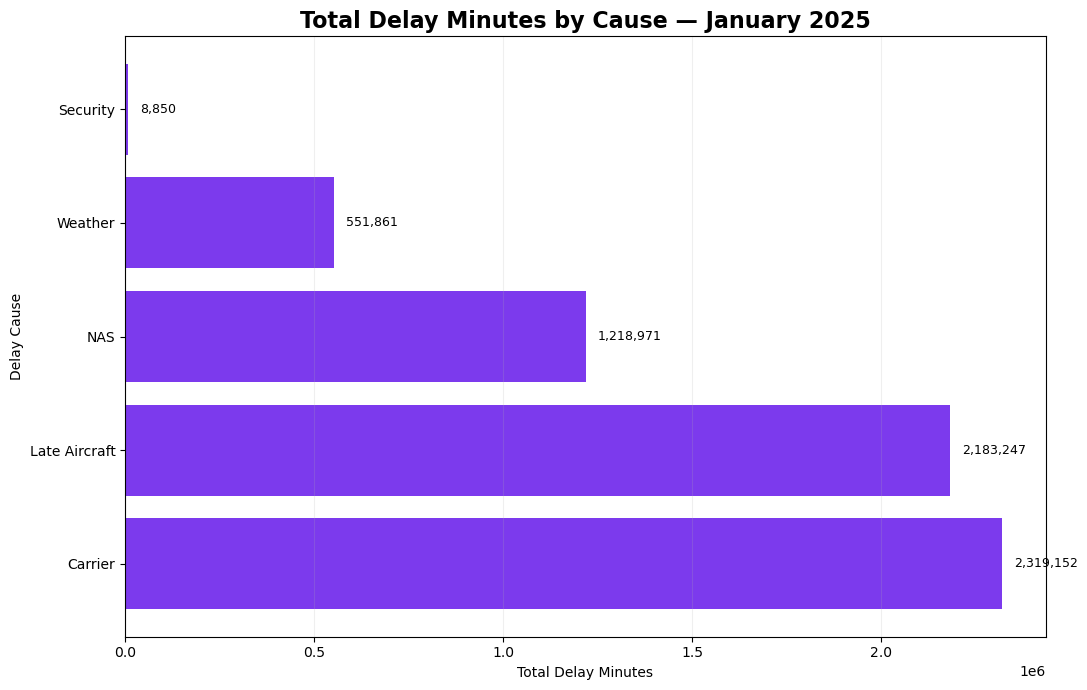

In [72]:
plt.figure(figsize=(11, 7))

bars = plt.barh(
    delay_cause_summary["Delay_Cause"],
    delay_cause_summary["Total_Delay_Minutes"],
    color="#7C3AED"
)

plt.xlabel("Total Delay Minutes")
plt.ylabel("Delay Cause")

plt.title(
    "Total Delay Minutes by Cause — January 2025",
    fontsize=16,
    fontweight="bold"
)

plt.grid(
    axis="x",
    alpha=0.2
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + total_delay_minutes * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

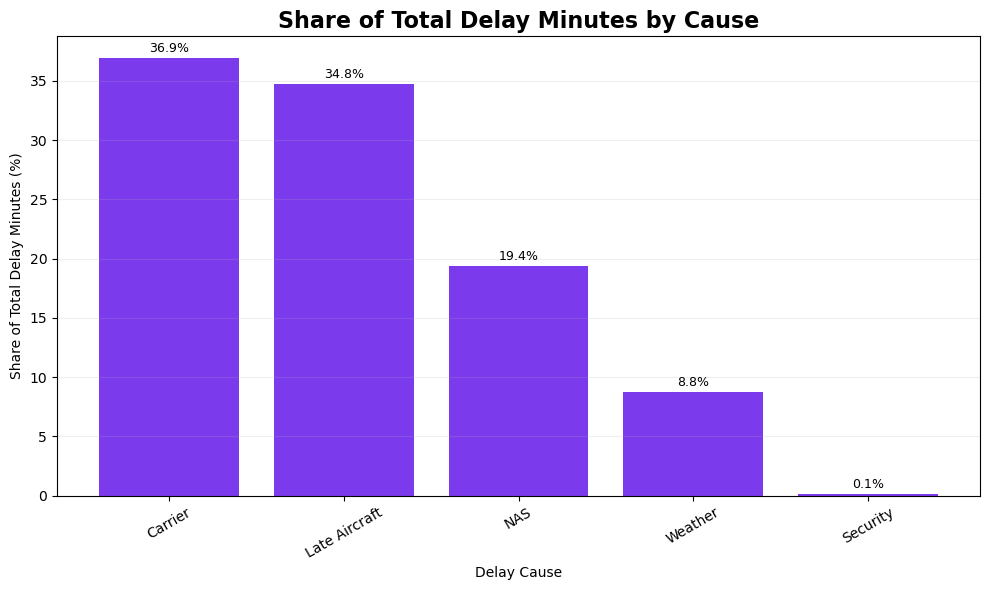

In [73]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    delay_cause_summary["Delay_Cause"],
    delay_cause_summary["Delay_Share"],
    color="#7C3AED"
)

plt.xlabel("Delay Cause")
plt.ylabel("Share of Total Delay Minutes (%)")

plt.title(
    "Share of Total Delay Minutes by Cause",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=30)

plt.grid(
    axis="y",
    alpha=0.2
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [74]:
top_delay_cause = delay_cause_summary.iloc[0]

print(
    f"Largest delay contributor: "
    f"{top_delay_cause['Delay_Cause']}"
)

print(
    f"Total delay minutes: "
    f"{top_delay_cause['Total_Delay_Minutes']:,.0f}"
)

print(
    f"Share of total delay minutes: "
    f"{top_delay_cause['Delay_Share']:.2f}%"
)

Largest delay contributor: Carrier
Total delay minutes: 2,319,152
Share of total delay minutes: 36.92%


In [76]:
top_3_share = (
    delay_cause_summary
    .head(3)["Delay_Share"]
    .sum()
)

print(
    f"Top 3 delay causes contribute "
    f"{top_3_share:.2f}% of total delay minutes."
)

Top 3 delay causes contribute 91.07% of total delay minutes.


In [77]:
final_delay_cause_summary = (
    delay_cause_summary[
        [
            "Delay_Cause",
            "Total_Delay_Minutes",
            "Delay_Share"
        ]
    ]
    .copy()
)

final_delay_cause_summary["Total_Delay_Minutes"] = (
    final_delay_cause_summary["Total_Delay_Minutes"]
    .round(0)
    .astype(int)
)

final_delay_cause_summary

,Delay_Cause,Total_Delay_Minutes,Delay_Share
0,Carrier,2319152,36.92
4,Late Aircraft,2183247,34.75
2,NAS,1218971,19.40
1,Weather,551861,8.78
3,Security,8850,0.14


###  Business Interpretation
The delay-cause analysis shows that [Carrier] contributed the largest share of total delay minutes during January 2025, accounting for approximately [36.92]% of network delay. The next largest contributors were [Late Aircraft] and [Nas], contributing [34.75]% and [19.40]%, respectively

# INSIGHT 17 — Delay Cause Contribution
-  What is causing the delay
-  CarrierDelay
-  WeatherDelay
-  NASDelay
-  SecurityDelay
-  LateAircraftDelay

In [78]:
# DELAY CAUSE
delay_columns = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

cause_names = {
    "CarrierDelay": "Carrier",
    "WeatherDelay": "Weather",
    "NASDelay": "NAS",
    "SecurityDelay": "Security",
    "LateAircraftDelay": "Late Aircraft"
}

In [80]:
# DELAY FREQUENCY
cause_frequency = pd.DataFrame({
    "Delay_Cause": delay_columns,
    "Affected_Flights": [
        (df[column].fillna(0) > 0).sum()
        for column in delay_columns
    ]
})
cause_frequency["Delay_Cause"] = (
    cause_frequency["Delay_Cause"]
    .map(cause_names)
)

In [81]:
cause_frequency

,Delay_Cause,Affected_Flights
0,Carrier,48206
1,Weather,6569
2,NAS,45647
3,Security,411
4,Late Aircraft,39055


In [82]:
# FREQUENCY SHARE
total_cause_occurrences = (
    cause_frequency["Affected_Flights"].sum()
)

cause_frequency["Frequency_Share"] = (
    cause_frequency["Affected_Flights"]
    / total_cause_occurrences
    * 100
).round(2)

In [83]:
cause_frequency = (
    cause_frequency
    .sort_values(
        "Affected_Flights",
        ascending=False
    )
)

cause_frequency

,Delay_Cause,Affected_Flights,Frequency_Share
0,Carrier,48206,34.46
2,NAS,45647,32.63
4,Late Aircraft,39055,27.92
1,Weather,6569,4.70
3,Security,411,0.29


In [85]:
cause_impact = pd.DataFrame({
    "Delay_Cause": delay_columns,
    "Total_Delay_Minutes": [
        df[column].fillna(0).sum()
        for column in delay_columns
    ]
})
cause_impact["Delay_Cause"] = (
    cause_impact["Delay_Cause"]
    .map(cause_names)
)

In [87]:
# DELAY SHARE
total_delay_minutes = (
    cause_impact["Total_Delay_Minutes"].sum()
)

cause_impact["Impact_Share"] = (
    cause_impact["Total_Delay_Minutes"]
    / total_delay_minutes
    * 100
).round(2)
cause_analysis = cause_frequency.merge(
    cause_impact,
    on="Delay_Cause"
)

In [88]:
cause_analysis

,Delay_Cause,Affected_Flights,Frequency_Share,Total_Delay_Minutes,Impact_Share
0,Carrier,48206,34.46,2319152.0,36.92
1,NAS,45647,32.63,1218971.0,19.40
2,Late Aircraft,39055,27.92,2183247.0,34.75
3,Weather,6569,4.70,551861.0,8.78
4,Security,411,0.29,8850.0,0.14


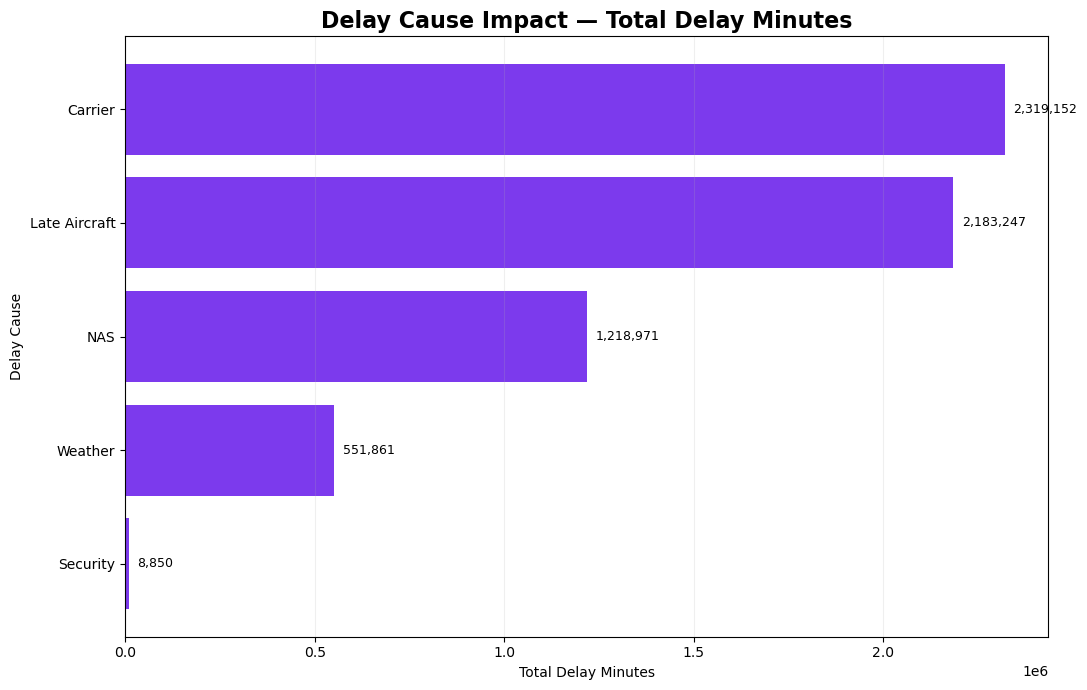

In [91]:
impact_chart = (
    cause_analysis
    .sort_values(
        "Total_Delay_Minutes",
        ascending=True
    )
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    impact_chart["Delay_Cause"],
    impact_chart["Total_Delay_Minutes"],
    color="#7C3AED"
)

plt.xlabel("Total Delay Minutes")
plt.ylabel("Delay Cause")

plt.title(
    "Delay Cause Impact — Total Delay Minutes",
    fontsize=16,
    fontweight="bold"
)

plt.grid(
    axis="x",
    alpha=0.2
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + impact_chart["Total_Delay_Minutes"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

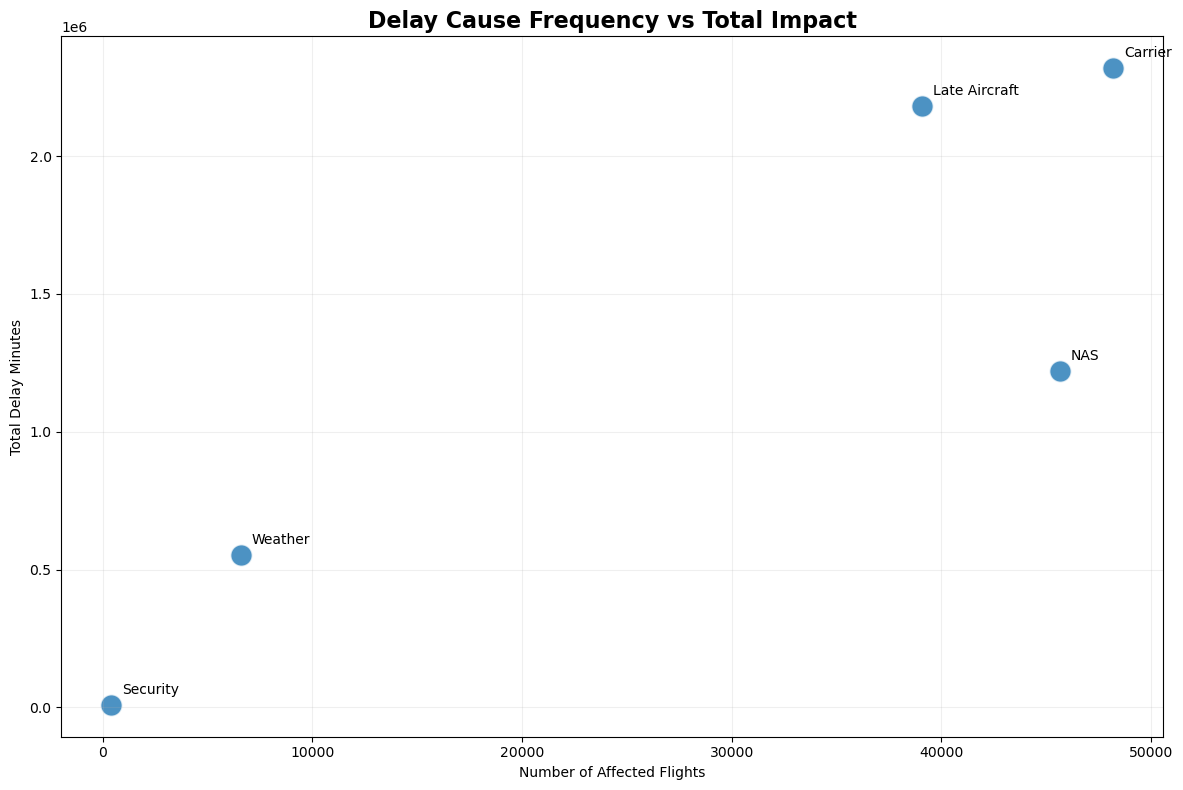

In [90]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=cause_analysis,
    x="Affected_Flights",
    y="Total_Delay_Minutes",
    s=250,
    alpha=0.8
)

for _, row in cause_analysis.iterrows():
    plt.annotate(
        row["Delay_Cause"],
        (
            row["Affected_Flights"],
            row["Total_Delay_Minutes"]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10
    )

plt.xlabel("Number of Affected Flights")
plt.ylabel("Total Delay Minutes")

plt.title(
    "Delay Cause Frequency vs Total Impact",
    fontsize=16,
    fontweight="bold"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [92]:
high_frequency_cause = cause_analysis.loc[
    cause_analysis["Affected_Flights"].idxmax()
]

print(
    f"Most frequent delay cause: "
    f"{high_frequency_cause['Delay_Cause']}"
)

print(
    f"Affected flights: "
    f"{high_frequency_cause['Affected_Flights']:,}"
)

Most frequent delay cause: Carrier
Affected flights: 48,206


In [93]:
highest_impact_cause = cause_analysis.loc[
    cause_analysis["Total_Delay_Minutes"].idxmax()
]

print(
    f"Highest-impact delay cause: "
    f"{highest_impact_cause['Delay_Cause']}"
)

print(
    f"Total delay minutes: "
    f"{highest_impact_cause['Total_Delay_Minutes']:,.0f}"
)

Highest-impact delay cause: Carrier
Total delay minutes: 2,319,152


In [95]:
portfolio_cause_summary = (
    cause_analysis[
        [
            "Delay_Cause",
            "Affected_Flights",
            "Frequency_Share",
            "Total_Delay_Minutes",
            "Impact_Share",
            
        ]
    ]
    .copy()
)

portfolio_cause_summary

,Delay_Cause,Affected_Flights,Frequency_Share,Total_Delay_Minutes,Impact_Share
0,Carrier,48206,34.46,2319152.0,36.92
1,NAS,45647,32.63,1218971.0,19.40
2,Late Aircraft,39055,27.92,2183247.0,34.75
3,Weather,6569,4.70,551861.0,8.78
4,Security,411,0.29,8850.0,0.14


# INSIGHT 18 — Airline × Delay Cause
-  Why is each airline experiencing delays

In [96]:
# DELAY CAUSE
delay_columns = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

cause_names = {
    "CarrierDelay": "Carrier",
    "WeatherDelay": "Weather",
    "NASDelay": "NAS",
    "SecurityDelay": "Security",
    "LateAircraftDelay": "Late Aircraft"
}

In [101]:
airline_delay_causes=df.groupby('Reporting_Airline')[delay_columns].sum().reset_index()
airline_delay_causes = airline_delay_causes.rename(
    columns=cause_names
)

airline_delay_causes.head()

,Reporting_Airline,Carrier,Weather,NAS,Security,Late Aircraft
0,AA,413376.0,81734.0,188499.0,1969.0,424388.0
1,AS,48474.0,11786.0,39258.0,1163.0,57916.0
2,B6,81987.0,5995.0,65543.0,528.0,109358.0
3,DL,473239.0,131009.0,222491.0,296.0,305736.0
4,F9,88123.0,10853.0,57821.0,0.0,147311.0


In [102]:
# TOTAL DELAY MINUTES PER AIRLINE
airline_delay_causes["Total_Delay_Minutes"] = (
    airline_delay_causes[
        ["Carrier", "Weather", "NAS", "Security", "Late Aircraft"]
    ].sum(axis=1)
)

airline_delay_causes


,Reporting_Airline,Carrier,Weather,NAS,Security,Late Aircraft,Total_Delay_Minutes
0,AA,413376.0,81734.0,188499.0,1969.0,424388.0,1109966.0
1,AS,48474.0,11786.0,39258.0,1163.0,57916.0,158597.0
2,B6,81987.0,5995.0,65543.0,528.0,109358.0,263411.0
3,DL,473239.0,131009.0,222491.0,296.0,305736.0,1132771.0
4,F9,88123.0,10853.0,57821.0,0.0,147311.0,304108.0
5,G4,13621.0,9247.0,7886.0,86.0,19552.0,50392.0
6,NK,1028.0,35.0,1973.0,0.0,1650.0,4686.0
7,OH,122939.0,46314.0,63227.0,925.0,196021.0,429426.0
8,OO,541772.0,181519.0,156670.0,1020.0,235074.0,1116055.0
9,UA,225300.0,29376.0,170665.0,0.0,248856.0,674197.0


In [103]:
# EACH SHARE
cause_columns = [
    "Carrier",
    "Weather",
    "NAS",
    "Security",
    "Late Aircraft"
]

for column in cause_columns:
    airline_delay_causes[f"{column}_Share"] = (
        airline_delay_causes[column]
        / airline_delay_causes["Total_Delay_Minutes"]
        * 100
    )

airline_delay_causes.head()

,Reporting_Airline,Carrier,Weather,NAS,Security,Late Aircraft,Total_Delay_Minutes,Carrier_Share,Weather_Share,NAS_Share,Security_Share,Late Aircraft_Share
0,AA,413376.0,81734.0,188499.0,1969.0,424388.0,1109966.0,37.242222,7.363649,16.982412,0.177393,38.234324
1,AS,48474.0,11786.0,39258.0,1163.0,57916.0,158597.0,30.564260,7.431414,24.753306,0.733305,36.517715
2,B6,81987.0,5995.0,65543.0,528.0,109358.0,263411.0,31.125124,2.275911,24.882408,0.200447,41.516110
3,DL,473239.0,131009.0,222491.0,296.0,305736.0,1132771.0,41.777111,11.565356,19.641304,0.026131,26.990098
4,F9,88123.0,10853.0,57821.0,0.0,147311.0,304108.0,28.977534,3.568798,19.013311,0.000000,48.440357


In [104]:
share_columns = [
    "Carrier_Share",
    "Weather_Share",
    "NAS_Share",
    "Security_Share",
    "Late Aircraft_Share"
]

airline_cause_share = airline_delay_causes[
    ["Reporting_Airline", "Total_Delay_Minutes"] + share_columns
].copy()

airline_cause_share[share_columns] = (
    airline_cause_share[share_columns]
    .round(2)
)

airline_cause_share = airline_cause_share.sort_values(
    "Total_Delay_Minutes",
    ascending=False
)

airline_cause_share

,Reporting_Airline,Total_Delay_Minutes,Carrier_Share,Weather_Share,NAS_Share,Security_Share,Late Aircraft_Share
3,DL,1132771.0,41.78,11.57,19.64,0.03,26.99
8,OO,1116055.0,48.54,16.26,14.04,0.09,21.06
0,AA,1109966.0,37.24,7.36,16.98,0.18,38.23
10,WN,806854.0,29.70,4.09,19.96,0.33,45.91
9,UA,674197.0,33.42,4.36,25.31,0.00,36.91
7,OH,429426.0,28.63,10.79,14.72,0.22,45.65
4,F9,304108.0,28.98,3.57,19.01,0.00,48.44
2,B6,263411.0,31.13,2.28,24.88,0.20,41.52
11,YX,231618.0,30.06,4.76,36.21,0.08,28.90
1,AS,158597.0,30.56,7.43,24.75,0.73,36.52


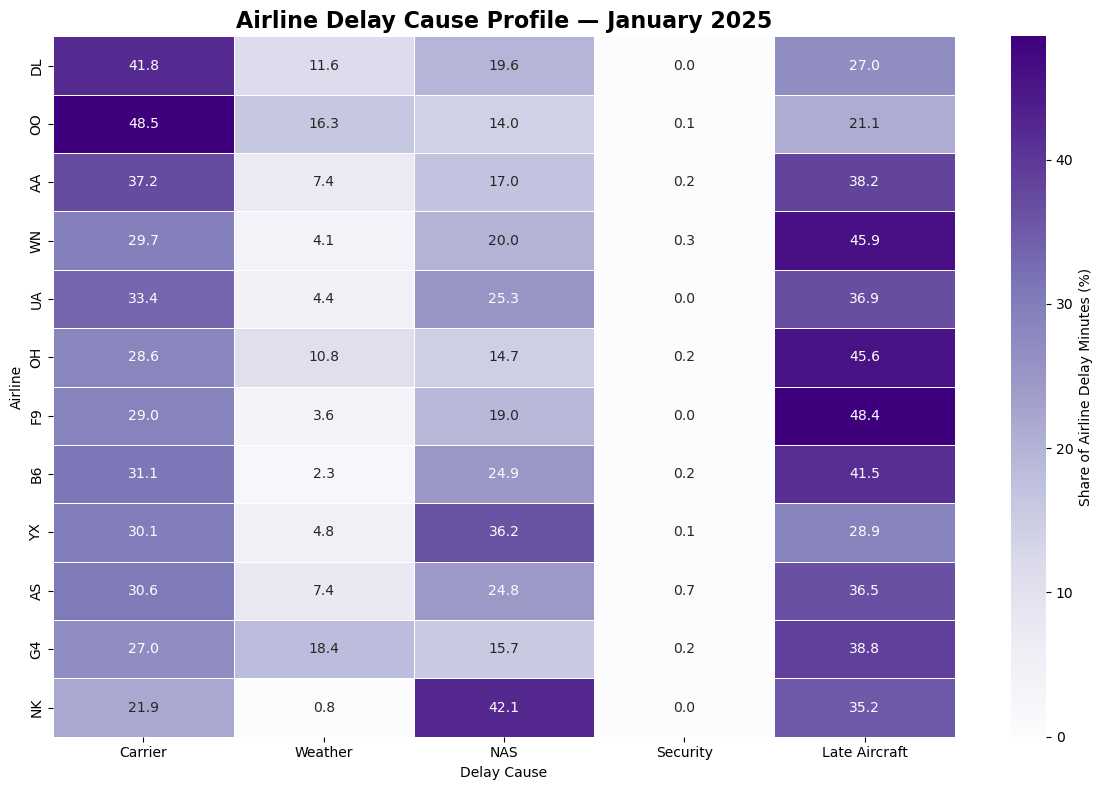

In [105]:
# VISUALISATION
heatmap_data = airline_cause_share.set_index(
    "Reporting_Airline"
)[share_columns]

heatmap_data = heatmap_data.rename(
    columns={
        "Carrier_Share": "Carrier",
        "Weather_Share": "Weather",
        "NAS_Share": "NAS",
        "Security_Share": "Security",
        "Late Aircraft_Share": "Late Aircraft"
    }
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Purples",
    linewidths=0.5,
    cbar_kws={
        "label": "Share of Airline Delay Minutes (%)"
    }
)

plt.xlabel("Delay Cause")
plt.ylabel("Airline")

plt.title(
    "Airline Delay Cause Profile — January 2025",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [106]:
top_cause_by_airline = heatmap_data.idxmax(axis=1)

top_cause_share_by_airline = heatmap_data.max(axis=1)

airline_top_cause = pd.DataFrame({
    "Top_Delay_Cause": top_cause_by_airline,
    "Top_Cause_Share": top_cause_share_by_airline
}).reset_index()

airline_top_cause["Top_Cause_Share"] = (
    airline_top_cause["Top_Cause_Share"]
    .round(2)
)

airline_top_cause

,Reporting_Airline,Top_Delay_Cause,Top_Cause_Share
0,DL,Carrier,41.78
1,OO,Carrier,48.54
2,AA,Late Aircraft,38.23
3,WN,Late Aircraft,45.91
4,UA,Late Aircraft,36.91
5,OH,Late Aircraft,45.65
6,F9,Late Aircraft,48.44
7,B6,Late Aircraft,41.52
8,YX,NAS,36.21
9,AS,Late Aircraft,36.52


In [107]:
airline_flight_volume = (
    df.groupby("Reporting_Airline")
      .size()
      .reset_index(name="Total_Flights")
)

airline_cause_summary = airline_top_cause.merge(
    airline_flight_volume,
    on="Reporting_Airline"
)

airline_cause_summary = airline_cause_summary.merge(
    airline_delay_causes[
        [
            "Reporting_Airline",
            "Total_Delay_Minutes"
        ]
    ],
    on="Reporting_Airline"
)

airline_cause_summary = airline_cause_summary.sort_values(
    "Total_Delay_Minutes",
    ascending=False
)

airline_cause_summary

,Reporting_Airline,Top_Delay_Cause,Top_Cause_Share,Total_Flights,Total_Delay_Minutes
0,DL,Carrier,41.78,76306,1132771.0
1,OO,Carrier,48.54,65036,1116055.0
2,AA,Late Aircraft,38.23,75088,1109966.0
3,WN,Late Aircraft,45.91,105307,806854.0
4,UA,Late Aircraft,36.91,62007,674197.0
5,OH,Late Aircraft,45.65,21094,429426.0
6,F9,Late Aircraft,48.44,15526,304108.0
7,B6,Late Aircraft,41.52,17918,263411.0
8,YX,NAS,36.21,27833,231618.0
9,AS,Late Aircraft,36.52,18163,158597.0


# INSIGHT 19 — Traffic vs Airport Reliability
-  Which airports handle a large amount of traffic while also having relatively poor delay performance

In [108]:
# TOTAL FLIGHTS
airport_flights = (
    df.groupby("Origin")
      .size()
      .reset_index(name="Total_Flights")
)

airport_flights.head()

,Origin,Total_Flights
0,ABE,135
1,ABQ,1705
2,ABR,61
3,ABY,74
4,ACT,93


In [110]:
# DELAYED FLIGHTS
airport_delays = (
    df.groupby("Origin")["IsDelayed15"]
      .sum()
      .reset_index(name="Delayed_15_Flights")
)

airport_delays.head()

,Origin,Delayed_15_Flights
0,ABE,17
1,ABQ,203
2,ABR,8
3,ABY,13
4,ACT,22


In [113]:
# COMBINE
airport_analysis = airport_flights.merge(
    airport_delays,
    on="Origin"
)

airport_analysis.head()

,Origin,Total_Flights,Delayed_15_Flights
0,ABE,135,17
1,ABQ,1705,203
2,ABR,61,8
3,ABY,74,13
4,ACT,93,22


In [114]:
# DELAY RATE
airport_analysis["Delay_Rate"] = (
    airport_analysis["Delayed_15_Flights"]
    / airport_analysis["Total_Flights"]
    * 100
).round(2)

airport_analysis.head()

,Origin,Total_Flights,Delayed_15_Flights,Delay_Rate
0,ABE,135,17,12.59
1,ABQ,1705,203,11.91
2,ABR,61,8,13.11
3,ABY,74,13,17.57
4,ACT,93,22,23.66


In [115]:
overall_delay_rate = (
    df["IsDelayed15"].mean() * 100
)

print(
    f"Overall Network Delay Rate: "
    f"{overall_delay_rate:.2f}%"
)

Overall Network Delay Rate: 18.23%


In [116]:
# REMOVE SMALL AIRPORTS
minimum_flights = 1000

airport_reliable_sample = (
    airport_analysis[
        airport_analysis["Total_Flights"] >= minimum_flights
    ]
    .copy()
)


In [117]:
# BUSIEST AIRPORT
airport_volume_performance = (
    airport_reliable_sample
    .sort_values(
        "Total_Flights",
        ascending=False
    )
)

airport_volume_performance.head(15)

,Origin,Total_Flights,Delayed_15_Flights,Delay_Rate
79,DEN,24701,6061,24.54
15,ATL,23096,5079,21.99
80,DFW,19275,4155,21.56
213,ORD,18702,3843,20.55
62,CLT,16098,2981,18.52
224,PHX,15066,1840,12.21
163,LAX,14136,1795,12.70
161,LAS,12906,1965,15.23
268,SEA,11740,1842,15.69
181,MCO,11558,2216,19.17


In [119]:
# TRAFFIC THRESHOLD
traffic_threshold = (
    airport_reliable_sample["Total_Flights"]
    .median()
)

print(
    f"Traffic Threshold: "
    f"{traffic_threshold:,.0f} flights"
)
delay_threshold = (
    airport_reliable_sample["Delay_Rate"]
    .median()
)

print(
    f"Delay Threshold: "
    f"{delay_threshold:.2f}%"
)

Traffic Threshold: 3,301 flights
Delay Threshold: 16.35%


In [121]:
airport_reliable_sample["Airport_Segment"] = np.select(
    [
        (
            (airport_reliable_sample["Total_Flights"] >= traffic_threshold) &
            (airport_reliable_sample["Delay_Rate"] >= delay_threshold)
        ),
        (
            (airport_reliable_sample["Total_Flights"] >= traffic_threshold) &
            (airport_reliable_sample["Delay_Rate"] < delay_threshold)
        ),
        (
            (airport_reliable_sample["Total_Flights"] < traffic_threshold) &
            (airport_reliable_sample["Delay_Rate"] >= delay_threshold)
        )
    ],
    [
        "High Traffic / High Delay",
        "High Traffic / Low Delay",
        "Low Traffic / High Delay"
    ],
    default="Low Traffic / Low Delay"
)

airport_reliable_sample[
    [
        "Origin",
        "Total_Flights",
        "Delay_Rate",
        "Airport_Segment"
    ]
].head(15)

,Origin,Total_Flights,Delay_Rate,Airport_Segment
1,ABQ,1705,11.91,Low Traffic / Low Delay
12,ANC,1187,14.49,Low Traffic / Low Delay
14,ASE,1025,31.71,Low Traffic / High Delay
15,ATL,23096,21.99,High Traffic / High Delay
17,AUS,5999,13.64,High Traffic / Low Delay
22,BDL,1752,19.46,Low Traffic / High Delay
27,BHM,1021,16.16,Low Traffic / Low Delay
35,BNA,6873,16.09,High Traffic / Low Delay
36,BOI,1789,13.58,Low Traffic / Low Delay
37,BOS,10018,20.14,High Traffic / High Delay


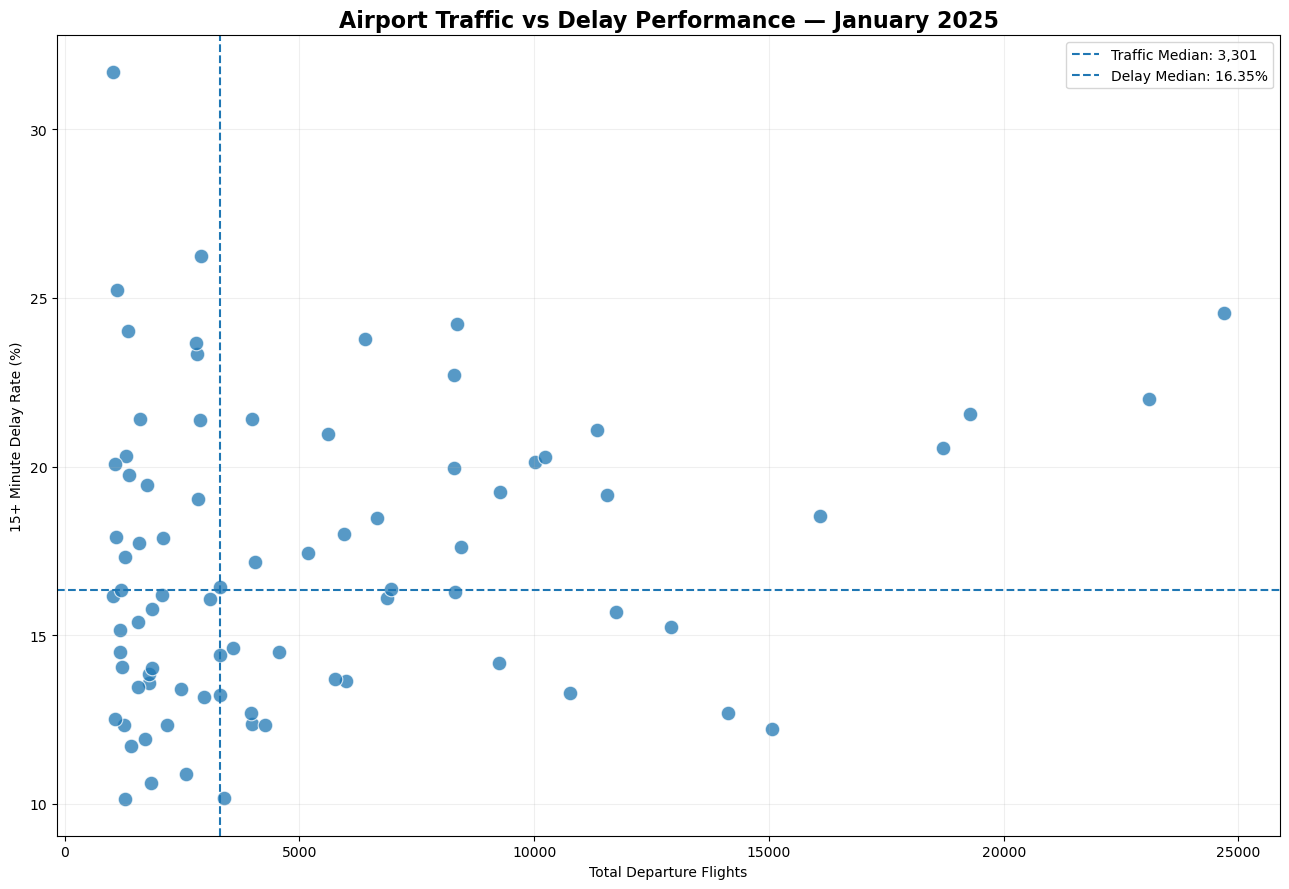

In [122]:
# VISUALISATION
plt.figure(figsize=(13, 9))

sns.scatterplot(
    data=airport_reliable_sample,
    x="Total_Flights",
    y="Delay_Rate",
    s=110,
    alpha=0.75
)

plt.axvline(
    traffic_threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"Traffic Median: {traffic_threshold:,.0f}"
)

plt.axhline(
    delay_threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"Delay Median: {delay_threshold:.2f}%"
)

plt.xlabel("Total Departure Flights")
plt.ylabel("15+ Minute Delay Rate (%)")

plt.title(
    "Airport Traffic vs Delay Performance — January 2025",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [125]:
high_priority_airports = (
    airport_reliable_sample[
        airport_reliable_sample["Airport_Segment"] ==
        "High Traffic / High Delay"
    ]
    .sort_values(
        ["Delay_Rate", "Total_Flights"],
        ascending=[False, False]
    )
)

high_priority_airports[
    [
        "Origin",
        "Total_Flights",
        "Delayed_15_Flights",
        "Delay_Rate",
        
    ]
].head(15)

,Origin,Total_Flights,Delayed_15_Flights,Delay_Rate
79,DEN,24701,6061,24.54
85,DTW,8362,2025,24.22
223,PHL,6405,1524,23.79
192,MIA,8296,1884,22.71
15,ATL,23096,5079,21.99
80,DFW,19275,4155,21.56
138,IAD,3994,855,21.41
76,DCA,11329,2389,21.09
105,FLL,5605,1175,20.96
213,ORD,18702,3843,20.55


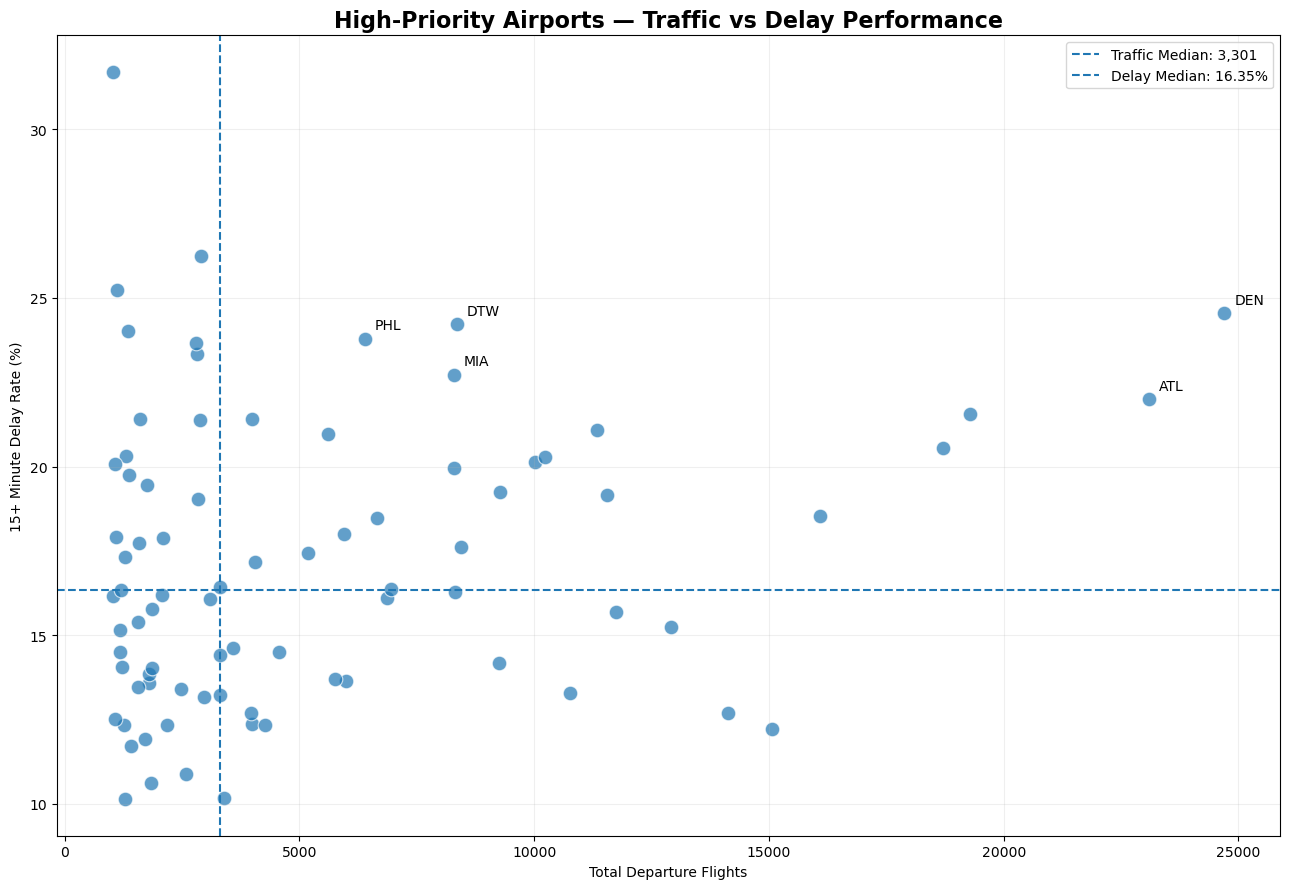

In [126]:
# MOST IMPORTANT AIRPORT
plt.figure(figsize=(13, 9))

sns.scatterplot(
    data=airport_reliable_sample,
    x="Total_Flights",
    y="Delay_Rate",
    s=110,
    alpha=0.7
)

plt.axvline(
    traffic_threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"Traffic Median: {traffic_threshold:,.0f}"
)

plt.axhline(
    delay_threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"Delay Median: {delay_threshold:.2f}%"
)

top_airports_to_label = (
    high_priority_airports
    .head(5)
)

for _, row in top_airports_to_label.iterrows():

    plt.annotate(
        row["Origin"],
        (
            row["Total_Flights"],
            row["Delay_Rate"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10
    )

plt.xlabel("Total Departure Flights")
plt.ylabel("15+ Minute Delay Rate (%)")

plt.title(
    "High-Priority Airports — Traffic vs Delay Performance",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### BUSINESS INTERPRETATION
Airport reliability varies substantially across the network, and the highest operational priorities are not necessarily the airports with the highest delay rates alone. By combining traffic volume with delay performance, we can identify airports where poor reliability occurs at meaningful operational scale. Airports classified as High Traffic / High Delay represent the most important candidates for further investigation because they combine substantial flight activity with weaker delay performance.

# INSIGHT 20 — Route Delay Performance: Best vs Worst Routes
-  Route Delay Performance: Best vs Worst Routes

In [127]:
# FLIGHT SUMMARY
route_flights = (
    df.groupby("Route")
      .size()
      .reset_index(name="Total_Flights")
)

route_delays = (
    df.groupby("Route")["IsDelayed15"]
      .sum()
      .reset_index(name="Delayed_15_Flights")
)

route_analysis = route_flights.merge(
    route_delays,
    on="Route"
)

route_analysis["Delay_Rate"] = (
    route_analysis["Delayed_15_Flights"]
    / route_analysis["Total_Flights"]
    * 100
).round(2)

In [128]:
# MIN 1000 FLIGHTS
minimum_flights = 100

route_reliable_sample = (
    route_analysis[
        route_analysis["Total_Flights"] >= minimum_flights
    ]
    .copy()
)

print(
    f"Routes included in ranking: "
    f"{len(route_reliable_sample):,}"
)

Routes included in ranking: 1,608


In [129]:
# WORST ROUTES
worst_routes = (
    route_reliable_sample
    .sort_values(
        "Delay_Rate",
        ascending=False
    )
)

worst_routes[
    [
        "Route",
        "Total_Flights",
        "Delayed_15_Flights",
        "Delay_Rate"
    ]
].head(20)

,Route,Total_Flights,Delayed_15_Flights,Delay_Rate
2217,HSV → DCA,101,45,44.55
3636,ORD → ASE,143,63,44.06
1348,DEN → MAF,119,50,42.02
582,BOS → PBI,238,99,41.60
590,BOS → RSW,204,83,40.69
1198,DCA → HSV,100,40,40.00
603,BOS → TPA,212,83,39.15
1270,DEN → BIS,124,48,38.71
636,BUF → DCA,114,44,38.60
428,BIS → DEN,124,47,37.90


In [130]:
# BEST ROUTES
best_routes = (
    route_reliable_sample
    .sort_values(
        "Delay_Rate",
        ascending=True
    )
)

best_routes[
    [
        "Route",
        "Total_Flights",
        "Delayed_15_Flights",
        "Delay_Rate"
    ]
].head(20)

,Route,Total_Flights,Delayed_15_Flights,Delay_Rate
2446,ITO → HNL,155,3,1.94
531,BOI → LAX,130,3,2.31
2117,HNL → ITO,155,5,3.23
2910,LIH → HNL,183,6,3.28
2568,KOA → HNL,183,6,3.28
2119,HNL → KOA,183,6,3.28
4000,PHX → CLT,247,9,3.64
2761,LAX → OGG,106,4,3.77
5433,YUM → PHX,105,4,3.81
2797,LBB → DAL,131,5,3.82


In [131]:
overall_delay_rate = (
    df["IsDelayed15"].mean() * 100
)

print(
    f"Overall Network Delay Rate: "
    f"{overall_delay_rate:.2f}%"
)

Overall Network Delay Rate: 18.23%


In [133]:
route_reliable_sample["vs_Overall"] = (
    route_reliable_sample["Delay_Rate"]
    - overall_delay_rate
).round(2)

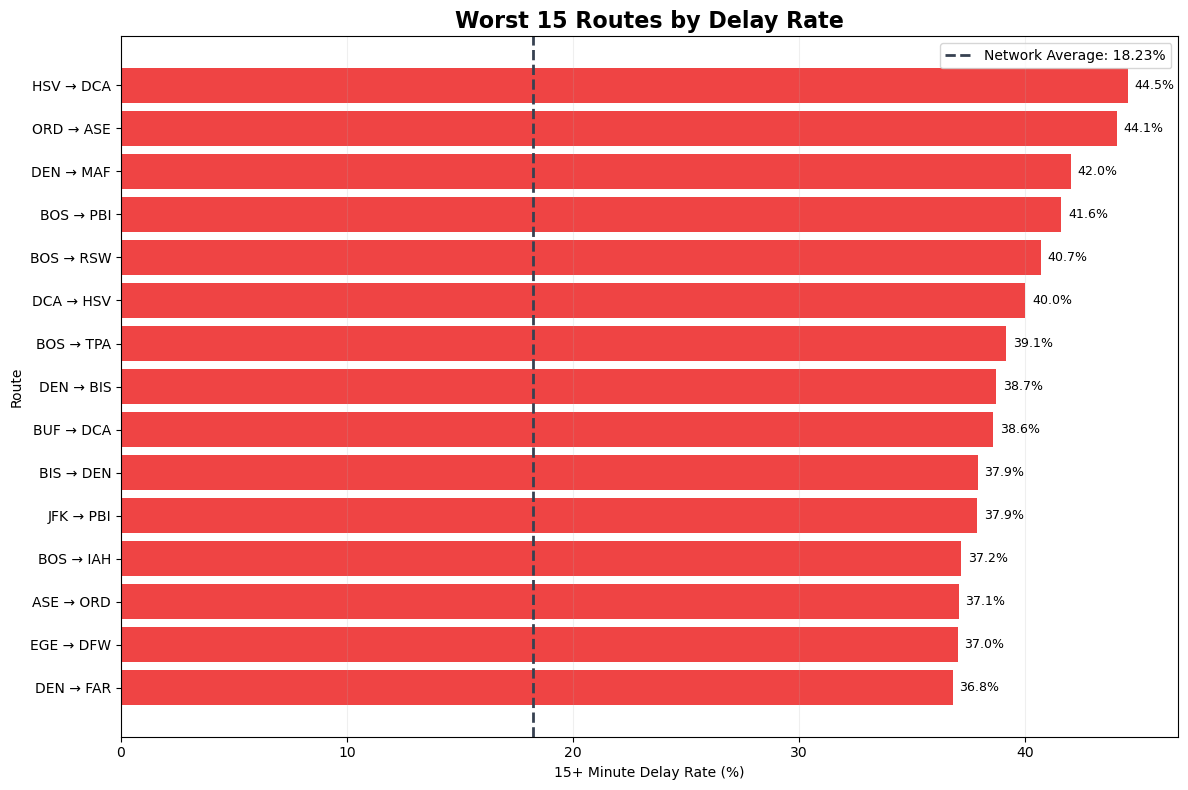

In [134]:
# WORST ROUTE CHART
top_15_worst = (
    worst_routes
    .head(15)
    .sort_values(
        "Delay_Rate",
        ascending=True
    )
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_15_worst["Route"],
    top_15_worst["Delay_Rate"],
    color="#EF4444"
)

plt.axvline(
    overall_delay_rate,
    linestyle="--",
    linewidth=2,
    color="#374151",
    label=f"Network Average: {overall_delay_rate:.2f}%"
)

plt.xlabel("15+ Minute Delay Rate (%)")
plt.ylabel("Route")

plt.title(
    "Worst 15 Routes by Delay Rate",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="x", alpha=0.2)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

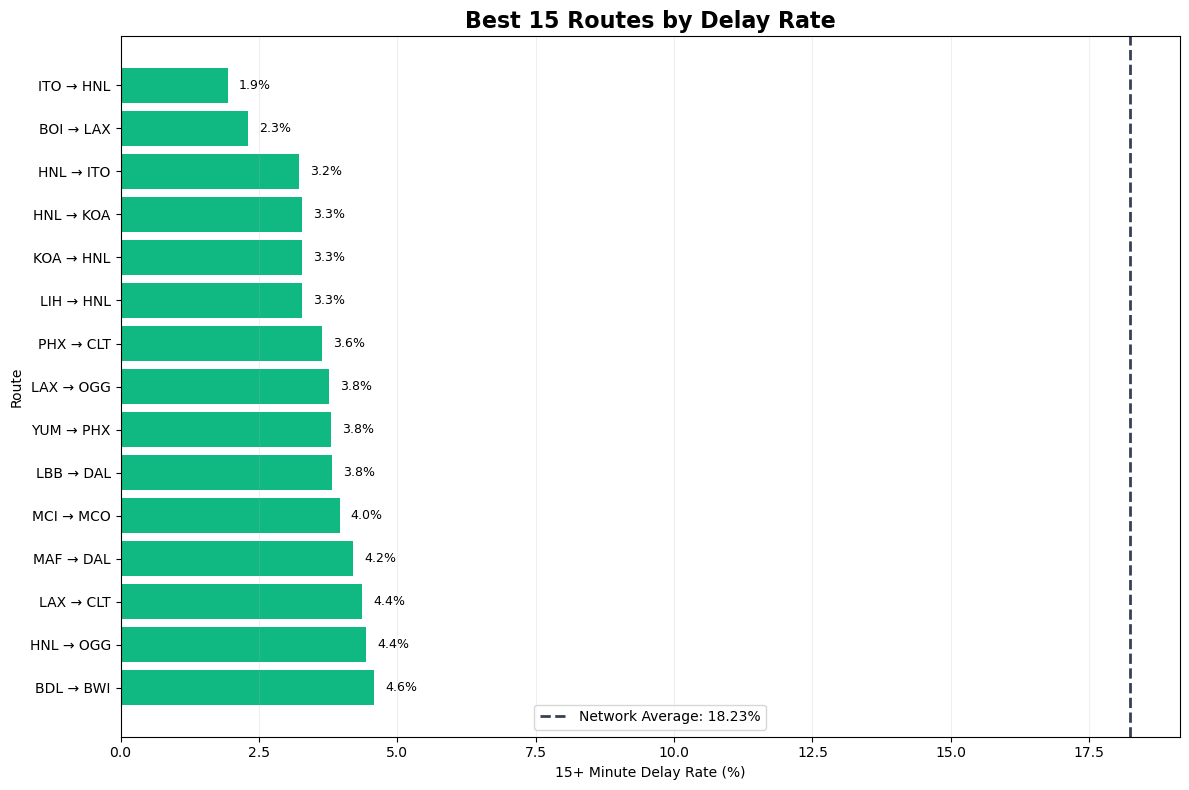

In [136]:
top_15_best = (
    best_routes
    .head(15)
    .sort_values(
        "Delay_Rate",
        ascending=False
    )
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_15_best["Route"],
    top_15_best["Delay_Rate"],
    color="#10B981"
)

plt.axvline(
    overall_delay_rate,
    linestyle="--",
    linewidth=2,
    color="#374151",
    label=f"Network Average: {overall_delay_rate:.2f}%"
)

plt.xlabel("15+ Minute Delay Rate (%)")
plt.ylabel("Route")

plt.title(
    "Best 15 Routes by Delay Rate",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="x", alpha=0.2)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [139]:
worst_route_business_view = (
    worst_routes[
        [
            "Route",
            "Total_Flights",
            "Delayed_15_Flights",
            "Delay_Rate",
            
        ]
    ]
    .head(20)
)

worst_route_business_view

,Route,Total_Flights,Delayed_15_Flights,Delay_Rate
2217,HSV → DCA,101,45,44.55
3636,ORD → ASE,143,63,44.06
1348,DEN → MAF,119,50,42.02
582,BOS → PBI,238,99,41.60
590,BOS → RSW,204,83,40.69
1198,DCA → HSV,100,40,40.00
603,BOS → TPA,212,83,39.15
1270,DEN → BIS,124,48,38.71
636,BUF → DCA,114,44,38.60
428,BIS → DEN,124,47,37.90


In [140]:
traffic_threshold = (
    route_reliable_sample["Total_Flights"].median()
)

high_priority_routes = (
    route_reliable_sample[
        (
            route_reliable_sample["Total_Flights"]
            >= traffic_threshold
        )
        &
        (
            route_reliable_sample["Delay_Rate"]
            > overall_delay_rate
        )
    ]
    .sort_values(
        ["Delay_Rate", "Total_Flights"],
        ascending=[False, False]
    )
)

high_priority_routes[
    [
        "Route",
        "Total_Flights",
        "Delayed_15_Flights",
        "Delay_Rate",
        "vs_Overall"
    ]
].head(20)

,Route,Total_Flights,Delayed_15_Flights,Delay_Rate,vs_Overall
582,BOS → PBI,238,99,41.60,23.37
590,BOS → RSW,204,83,40.69,22.46
603,BOS → TPA,212,83,39.15,20.92
2530,JFK → PBI,198,75,37.88,19.65
574,BOS → MCO,339,123,36.28,18.05
1647,DTW → MCO,198,70,35.35,17.12
1033,CPR → DEN,186,65,34.95,16.72
562,BOS → FLL,220,76,34.55,16.32
1295,DEN → DRO,186,64,34.41,16.18
1285,DEN → COS,436,148,33.94,15.71


### BUSINESS INTERPRETATION
Route reliability varies significantly across the network. The worst-performing routes show substantially higher 15+ minute delay rates than the overall network benchmark, while some high-volume routes maintain comparatively strong reliability.